In [1]:
# ============================================================
# MLBFD — PHASE 2, CELL 1
# Multi-Layer Behavioral Fraud Detection System
# for Indian Digital Payments Using Machine Learning
# ============================================================
# Setup, Load Data, SMOTE Balancing
# Notebook: MLBFD_Phase2_Model_Training.ipynb
# ============================================================

# --- Install required libraries ---
!pip install xgboost lightgbm shap imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import pickle
import os
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, precision_recall_curve,
                             average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# Plotting setup
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

PROJECT_NAME = "MLBFD — Multi-Layer Behavioral Fraud Detection"
print(f"{'='*60}")
print(f"  {PROJECT_NAME}")
print(f"  Phase 2: ML Model Training")
print(f"{'='*60}")
print("✅ All libraries loaded successfully\n")

# --- Load Dataset ---
print(f"{'='*60}")
print("LOADING DATASETS")
print(f"{'='*60}")

df_ml = pd.read_csv('mlbfd_ml_ready.csv')
df_users = pd.read_csv('mlbfd_user_profiles.csv')

print(f"✅ ML-ready dataset : {len(df_ml):,} rows, {df_ml.shape[1]} columns")
print(f"✅ User profiles    : {len(df_users):,} users")

# --- Dataset Overview ---
print(f"\n--- Class Distribution (BEFORE SMOTE) ---")
class_counts = df_ml['is_fraud'].value_counts()
print(f"  Legitimate : {class_counts[0]:,} ({class_counts[0]/len(df_ml)*100:.2f}%)")
print(f"  Fraud      : {class_counts[1]:,} ({class_counts[1]/len(df_ml)*100:.2f}%)")
print(f"  Imbalance  : 1 fraud per {class_counts[0]//class_counts[1]} legitimate")

# --- Prepare Features & Target ---
X = df_ml.drop(columns=['is_fraud'])
y = df_ml['is_fraud']

# Handle any remaining non-numeric columns
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

# Handle NaN/Inf values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

print(f"\n✅ Features prepared: {X.shape[1]} columns")
print(f"   Target: is_fraud (0/1)")

# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n--- Train/Test Split ---")
print(f"  Training set   : {len(X_train):,} rows")
print(f"  Testing set    : {len(X_test):,} rows")
print(f"  Train fraud    : {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"  Test fraud     : {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

# --- SMOTE Balancing ---
print(f"\n{'='*60}")
print("SMOTE — SYNTHETIC MINORITY OVERSAMPLING")
print(f"{'='*60}")

print(f"\nBefore SMOTE:")
print(f"  Legitimate : {(y_train==0).sum():,}")
print(f"  Fraud      : {(y_train==1).sum():,}")

smote = SMOTE(random_state=42, sampling_strategy=1.0)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Legitimate : {(y_train_smote==0).sum():,}")
print(f"  Fraud      : {(y_train_smote==1).sum():,}")
print(f"  Total      : {len(X_train_smote):,}")
print(f"  Ratio      : {(y_train_smote==1).sum()/(y_train_smote==0).sum()*100:.1f}% (balanced ✅)")

# --- Scale Features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Keep unscaled versions for tree-based models
X_train_tree = X_train_smote.values
X_test_tree = X_test.values

print(f"\n✅ Features scaled with StandardScaler")
print(f"✅ Cell 1 Complete — Data ready for model training")
print(f"\n→ Run Cell 2: Train all 5 ML models")

  MLBFD — Multi-Layer Behavioral Fraud Detection
  Phase 2: ML Model Training
✅ All libraries loaded successfully

LOADING DATASETS
✅ ML-ready dataset : 333,726 rows, 58 columns
✅ User profiles    : 1,000 users

--- Class Distribution (BEFORE SMOTE) ---
  Legitimate : 330,753 (99.11%)
  Fraud      : 2,973 (0.89%)
  Imbalance  : 1 fraud per 111 legitimate

✅ Features prepared: 57 columns
   Target: is_fraud (0/1)

--- Train/Test Split ---
  Training set   : 266,980 rows
  Testing set    : 66,746 rows
  Train fraud    : 2,378 (0.89%)
  Test fraud     : 595 (0.89%)

SMOTE — SYNTHETIC MINORITY OVERSAMPLING

Before SMOTE:
  Legitimate : 264,602
  Fraud      : 2,378

After SMOTE:
  Legitimate : 264,602
  Fraud      : 264,602
  Total      : 529,204
  Ratio      : 100.0% (balanced ✅)

✅ Features scaled with StandardScaler
✅ Cell 1 Complete — Data ready for model training

→ Run Cell 2: Train all 5 ML models


In [2]:
# ============================================================
# MLBFD — PHASE 2, CELL 2
# Train All 5 ML Models
# ============================================================

print(f"{'='*60}")
print("TRAINING ALL 5 ML MODELS")
print(f"{'='*60}")

# Store results for comparison
results = {}
trained_models = {}

# ============================================================
# MODEL 1: LOGISTIC REGRESSION (Baseline)
# ============================================================
print(f"\n{'─'*50}")
print("MODEL 1: LOGISTIC REGRESSION (Baseline)")
print(f"{'─'*50}")

start = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_scaled, y_train_smote)
lr_time = time.time() - start

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, lr_pred),
    'precision': precision_score(y_test, lr_pred),
    'recall': recall_score(y_test, lr_pred),
    'f1': f1_score(y_test, lr_pred),
    'auc': roc_auc_score(y_test, lr_prob),
    'train_time': lr_time,
    'predictions': lr_pred,
    'probabilities': lr_prob
}
trained_models['Logistic Regression'] = lr_model

print(f"  ✅ Trained in {lr_time:.2f}s")
print(f"  Accuracy : {results['Logistic Regression']['accuracy']*100:.2f}%")
print(f"  Recall   : {results['Logistic Regression']['recall']*100:.2f}%")
print(f"  AUC      : {results['Logistic Regression']['auc']:.4f}")

# ============================================================
# MODEL 2: RANDOM FOREST
# ============================================================
print(f"\n{'─'*50}")
print("MODEL 2: RANDOM FOREST")
print(f"{'─'*50}")

start = time.time()
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train_tree, y_train_smote)
rf_time = time.time() - start

rf_pred = rf_model.predict(X_test_tree)
rf_prob = rf_model.predict_proba(X_test_tree)[:, 1]

results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, rf_pred),
    'precision': precision_score(y_test, rf_pred),
    'recall': recall_score(y_test, rf_pred),
    'f1': f1_score(y_test, rf_pred),
    'auc': roc_auc_score(y_test, rf_prob),
    'train_time': rf_time,
    'predictions': rf_pred,
    'probabilities': rf_prob
}
trained_models['Random Forest'] = rf_model

print(f"  ✅ Trained in {rf_time:.2f}s")
print(f"  Accuracy : {results['Random Forest']['accuracy']*100:.2f}%")
print(f"  Recall   : {results['Random Forest']['recall']*100:.2f}%")
print(f"  AUC      : {results['Random Forest']['auc']:.4f}")

# ============================================================
# MODEL 3: XGBOOST (PRIMARY — BEST MODEL)
# ============================================================
print(f"\n{'─'*50}")
print("MODEL 3: XGBOOST ⭐ (Primary Model)")
print(f"{'─'*50}")

start = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train_tree, y_train_smote)
xgb_time = time.time() - start

xgb_pred = xgb_model.predict(X_test_tree)
xgb_prob = xgb_model.predict_proba(X_test_tree)[:, 1]

results['XGBoost'] = {
    'accuracy': accuracy_score(y_test, xgb_pred),
    'precision': precision_score(y_test, xgb_pred),
    'recall': recall_score(y_test, xgb_pred),
    'f1': f1_score(y_test, xgb_pred),
    'auc': roc_auc_score(y_test, xgb_prob),
    'train_time': xgb_time,
    'predictions': xgb_pred,
    'probabilities': xgb_prob
}
trained_models['XGBoost'] = xgb_model

print(f"  ✅ Trained in {xgb_time:.2f}s")
print(f"  Accuracy : {results['XGBoost']['accuracy']*100:.2f}%")
print(f"  Recall   : {results['XGBoost']['recall']*100:.2f}%")
print(f"  AUC      : {results['XGBoost']['auc']:.4f}")

# ============================================================
# MODEL 4: NEURAL NETWORK (TensorFlow/Keras)
# ============================================================
print(f"\n{'─'*50}")
print("MODEL 4: NEURAL NETWORK (TensorFlow/Keras)")
print(f"{'─'*50}")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)

nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=0
)

start = time.time()
history = nn_model.fit(
    X_train_scaled, y_train_smote,
    epochs=50,
    batch_size=256,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=0
)
nn_time = time.time() - start

nn_prob = nn_model.predict(X_test_scaled, verbose=0).flatten()
nn_pred = (nn_prob >= 0.5).astype(int)

results['Neural Network'] = {
    'accuracy': accuracy_score(y_test, nn_pred),
    'precision': precision_score(y_test, nn_pred),
    'recall': recall_score(y_test, nn_pred),
    'f1': f1_score(y_test, nn_pred),
    'auc': roc_auc_score(y_test, nn_prob),
    'train_time': nn_time,
    'predictions': nn_pred,
    'probabilities': nn_prob
}
trained_models['Neural Network'] = nn_model

print(f"  ✅ Trained in {nn_time:.2f}s ({len(history.history['loss'])} epochs)")
print(f"  Accuracy : {results['Neural Network']['accuracy']*100:.2f}%")
print(f"  Recall   : {results['Neural Network']['recall']*100:.2f}%")
print(f"  AUC      : {results['Neural Network']['auc']:.4f}")

# ============================================================
# MODEL 5: ISOLATION FOREST (Unsupervised Anomaly Detection)
# ============================================================
print(f"\n{'─'*50}")
print("MODEL 5: ISOLATION FOREST (Unsupervised)")
print(f"{'─'*50}")

start = time.time()
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)
# Train on ORIGINAL data (not SMOTE) — unsupervised doesn't need balanced data
iso_model.fit(X_train_scaled)
iso_time = time.time() - start

# Isolation Forest returns -1 for anomaly, 1 for normal
iso_raw = iso_model.predict(X_test_scaled)
iso_pred = np.where(iso_raw == -1, 1, 0)  # Convert: -1 (anomaly) → 1 (fraud)
iso_scores = -iso_model.decision_function(X_test_scaled)  # Negative = more anomalous
iso_prob = (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min())  # Normalize 0-1

results['Isolation Forest'] = {
    'accuracy': accuracy_score(y_test, iso_pred),
    'precision': precision_score(y_test, iso_pred),
    'recall': recall_score(y_test, iso_pred),
    'f1': f1_score(y_test, iso_pred),
    'auc': roc_auc_score(y_test, iso_prob),
    'train_time': iso_time,
    'predictions': iso_pred,
    'probabilities': iso_prob
}
trained_models['Isolation Forest'] = iso_model

print(f"  ✅ Trained in {iso_time:.2f}s")
print(f"  Accuracy : {results['Isolation Forest']['accuracy']*100:.2f}%")
print(f"  Recall   : {results['Isolation Forest']['recall']*100:.2f}%")
print(f"  AUC      : {results['Isolation Forest']['auc']:.4f}")

# ============================================================
# MODEL COMPARISON TABLE
# ============================================================
print(f"\n{'='*60}")
print("📊 ALL 5 MODELS — COMPARISON TABLE")
print(f"{'='*60}")
print(f"\n{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10} {'Time':>8}")
print(f"{'─'*82}")

best_model_name = ''
best_auc = 0

for name, metrics in results.items():
    star = ' ⭐' if name == 'XGBoost' else ''
    print(f"{name:<22} {metrics['accuracy']*100:>9.2f}% {metrics['precision']*100:>9.2f}% "
          f"{metrics['recall']*100:>9.2f}% {metrics['f1']*100:>9.2f}% "
          f"{metrics['auc']:>9.4f} {metrics['train_time']:>7.2f}s{star}")

    if metrics['auc'] > best_auc:
        best_auc = metrics['auc']
        best_model_name = name

print(f"\n🏆 Best Model: {best_model_name} (AUC: {best_auc:.4f})")
print(f"\n✅ Cell 2 Complete — All 5 models trained!")
print(f"→ Run Cell 3: Visualizations & Confusion Matrices")

TRAINING ALL 5 ML MODELS

──────────────────────────────────────────────────
MODEL 1: LOGISTIC REGRESSION (Baseline)
──────────────────────────────────────────────────
  ✅ Trained in 2.28s
  Accuracy : 99.97%
  Recall   : 99.83%
  AUC      : 1.0000

──────────────────────────────────────────────────
MODEL 2: RANDOM FOREST
──────────────────────────────────────────────────
  ✅ Trained in 387.67s
  Accuracy : 100.00%
  Recall   : 100.00%
  AUC      : 1.0000

──────────────────────────────────────────────────
MODEL 3: XGBOOST ⭐ (Primary Model)
──────────────────────────────────────────────────
  ✅ Trained in 25.02s
  Accuracy : 99.99%
  Recall   : 100.00%
  AUC      : 1.0000

──────────────────────────────────────────────────
MODEL 4: NEURAL NETWORK (TensorFlow/Keras)
──────────────────────────────────────────────────
  ✅ Trained in 131.81s (12 epochs)
  Accuracy : 99.99%
  Recall   : 99.66%
  AUC      : 0.9991

──────────────────────────────────────────────────
MODEL 5: ISOLATION FOREST 

GENERATING MODEL EVALUATION VISUALIZATIONS


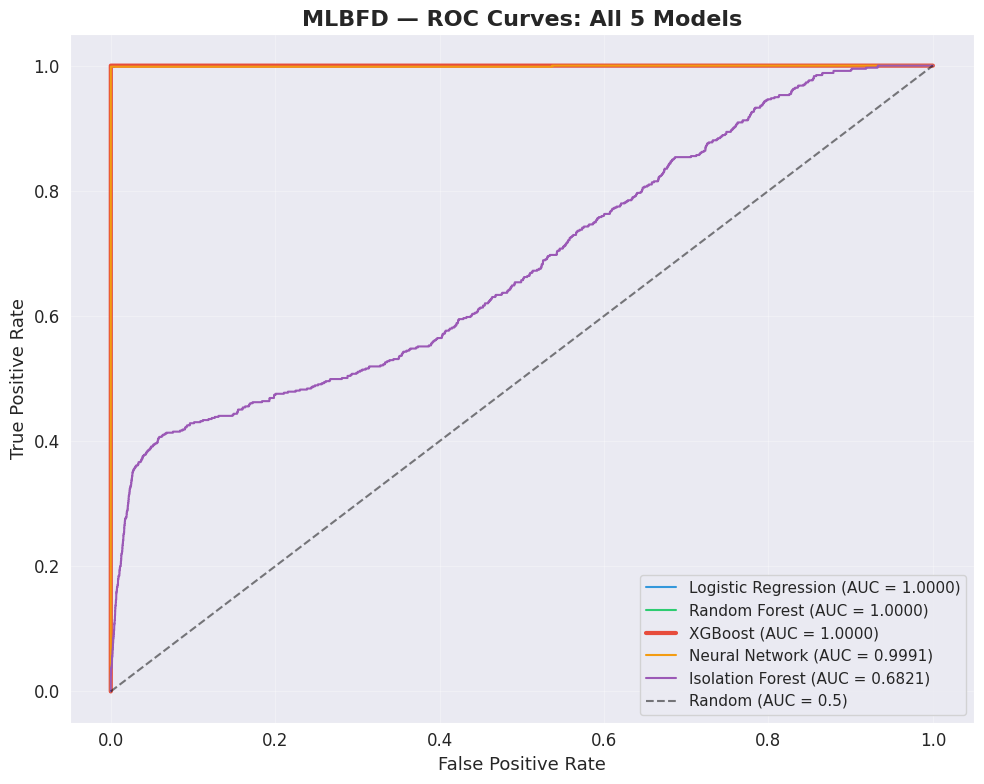

✅ Saved: mlbfd_roc_curves.png


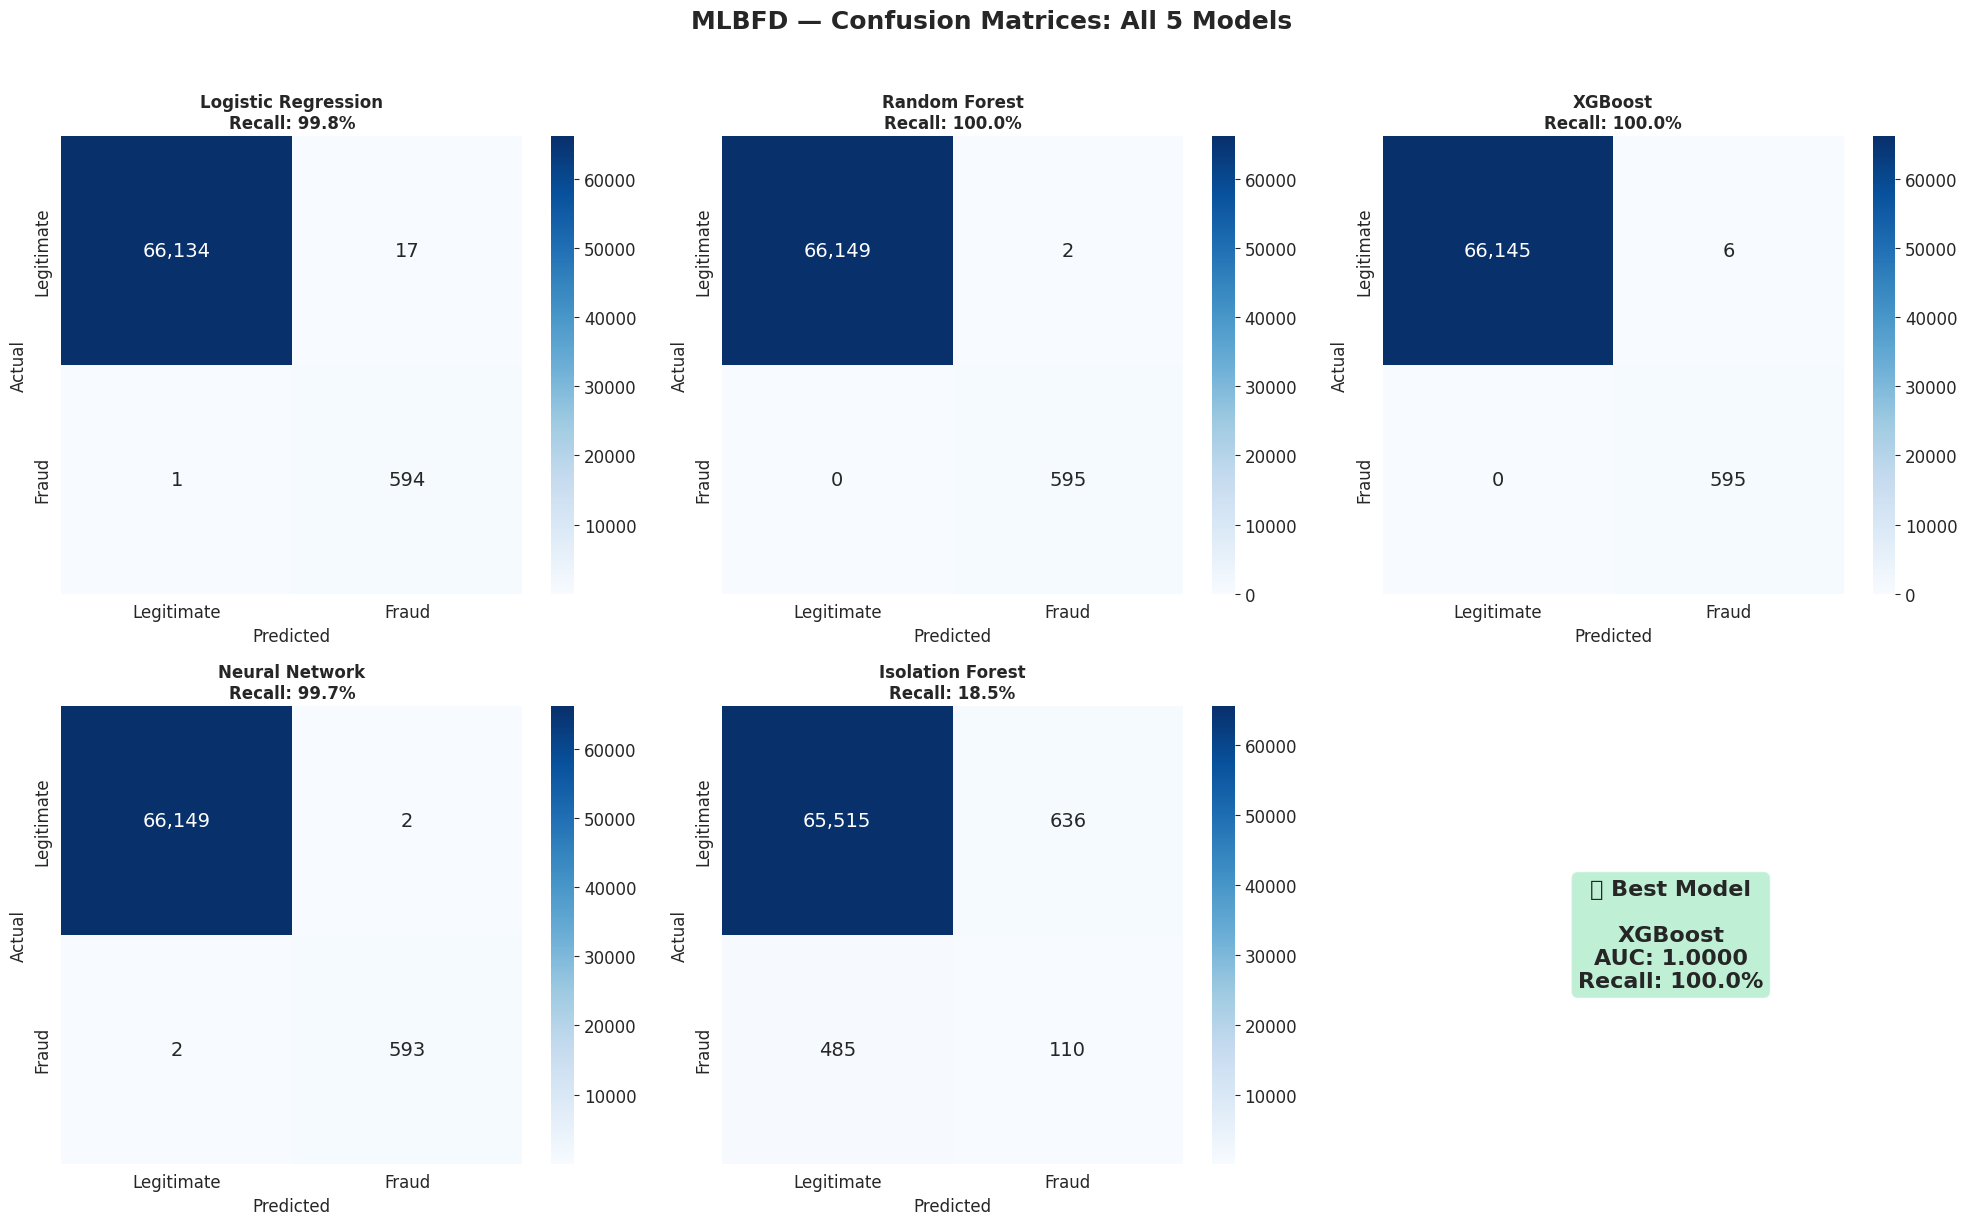

✅ Saved: mlbfd_confusion_matrices.png


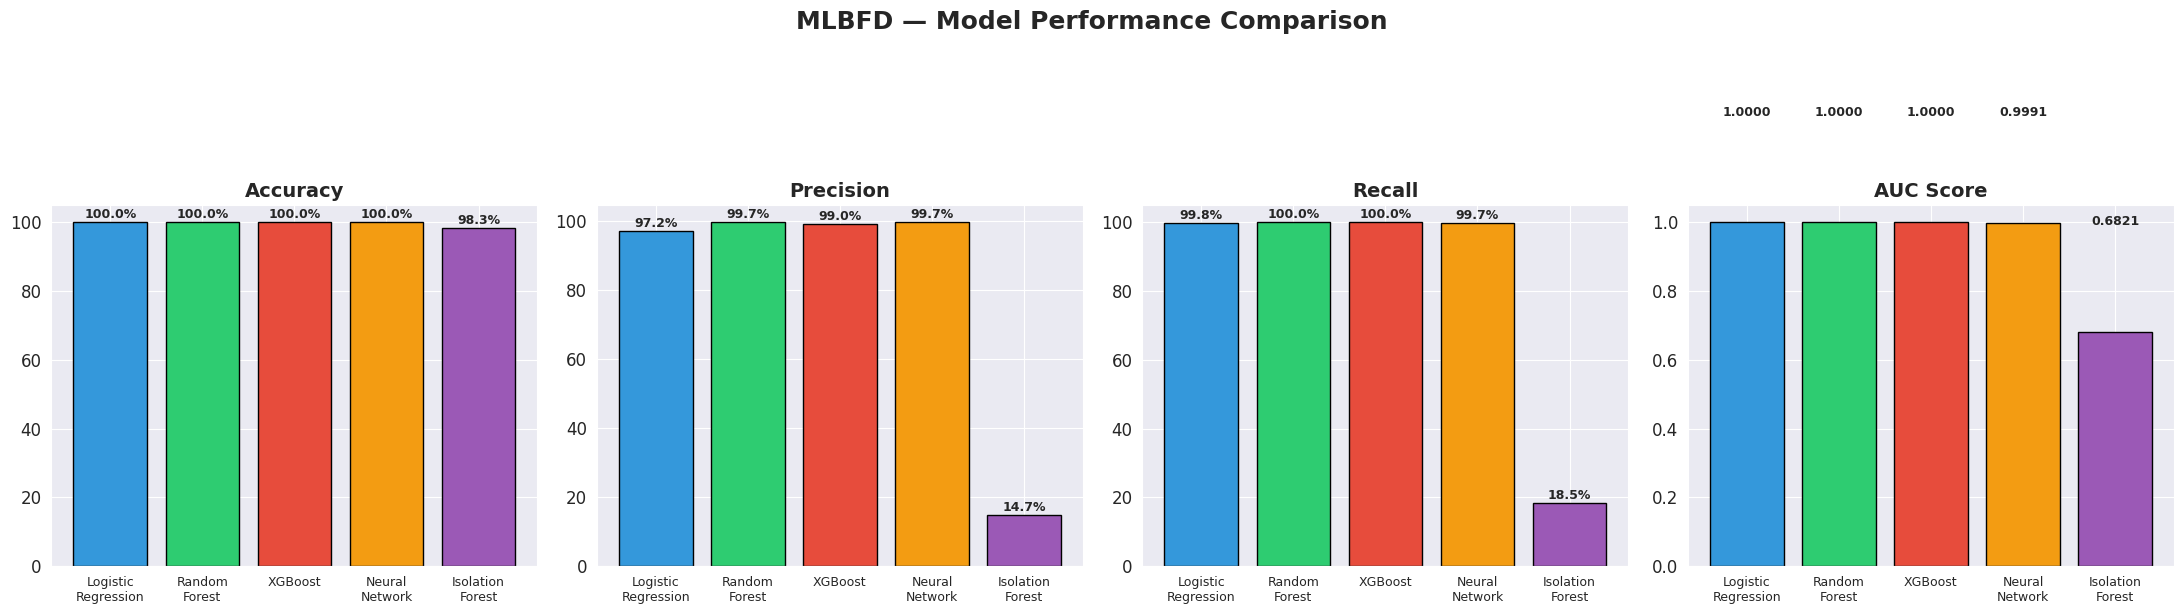

✅ Saved: mlbfd_model_comparison.png


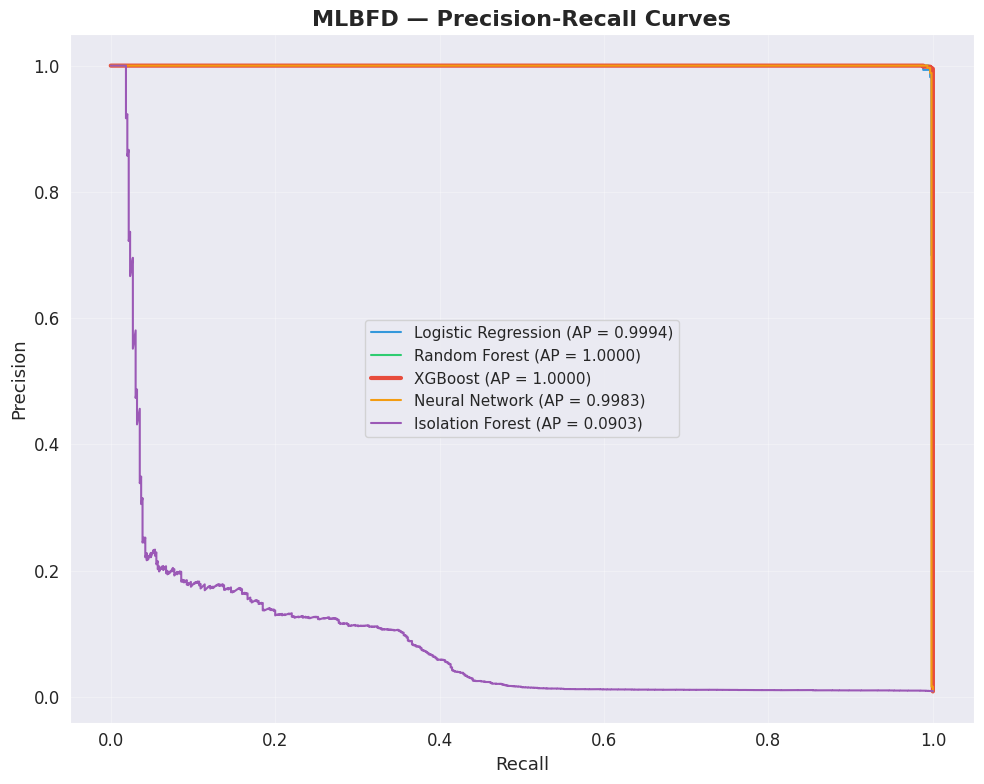

✅ Saved: mlbfd_precision_recall_curves.png


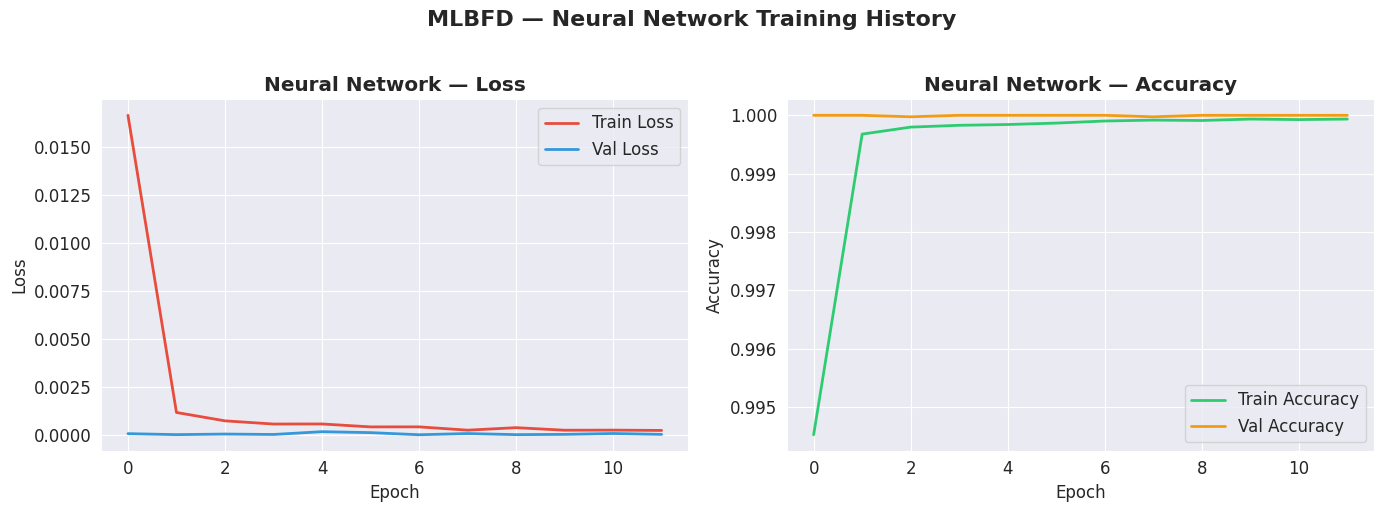

✅ Saved: mlbfd_nn_training_history.png

DETAILED CLASSIFICATION REPORTS

──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     66151
       Fraud       0.97      1.00      0.99       595

    accuracy                           1.00     66746
   macro avg       0.99      1.00      0.99     66746
weighted avg       1.00      1.00      1.00     66746


──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     66151
       Fraud       1.00      1.00      1.00       595

    accuracy                           1.00     66746
   macro avg       1.00      1.00      1.00     66746
weighted avg       1.00      1.00      1.00     66746


─────────────────────────────

In [3]:
# ============================================================
# MLBFD — PHASE 2, CELL 3
# Model Evaluation Visualizations
# ============================================================

print(f"{'='*60}")
print("GENERATING MODEL EVALUATION VISUALIZATIONS")
print(f"{'='*60}")

# ============================================================
# VIZ 1: ROC CURVES — All 5 Models
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
model_names = list(results.keys())

for i, (name, metrics) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, metrics['probabilities'])
    label = f"{name} (AUC = {metrics['auc']:.4f})"
    linewidth = 3 if name == 'XGBoost' else 1.5
    ax.plot(fpr, tpr, color=colors[i], label=label, linewidth=linewidth)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('MLBFD — ROC Curves: All 5 Models', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mlbfd_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: mlbfd_roc_curves.png")

# ============================================================
# VIZ 2: CONFUSION MATRICES — All 5 Models
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, (name, metrics) in enumerate(results.items()):
    cm = confusion_matrix(y_test, metrics['predictions'])
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[i],
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'],
                annot_kws={'size': 14})
    axes[i].set_title(f'{name}\nRecall: {metrics["recall"]*100:.1f}%',
                       fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

# Hide extra subplot
axes[5].axis('off')
axes[5].text(0.5, 0.5, f'🏆 Best Model\n\nXGBoost\nAUC: {results["XGBoost"]["auc"]:.4f}\nRecall: {results["XGBoost"]["recall"]*100:.1f}%',
             ha='center', va='center', fontsize=16, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='#2ecc71', alpha=0.3))

plt.suptitle('MLBFD — Confusion Matrices: All 5 Models', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mlbfd_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: mlbfd_confusion_matrices.png")

# ============================================================
# VIZ 3: MODEL COMPARISON BAR CHART
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

metrics_to_plot = ['accuracy', 'precision', 'recall', 'auc']
titles = ['Accuracy', 'Precision', 'Recall', 'AUC Score']
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    values = [results[name][metric] * 100 if metric != 'auc' else results[name][metric]
              for name in model_names]
    bars = axes[idx].bar(range(len(model_names)), values, color=colors_bar, edgecolor='black')
    axes[idx].set_title(title, fontweight='bold', fontsize=14)
    axes[idx].set_xticks(range(len(model_names)))
    axes[idx].set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=9)

    for bar, val in zip(bars, values):
        fmt = f'{val:.1f}%' if metric != 'auc' else f'{val:.4f}'
        axes[idx].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                       fmt, ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('MLBFD — Model Performance Comparison', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mlbfd_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: mlbfd_model_comparison.png")

# ============================================================
# VIZ 4: PRECISION-RECALL CURVES
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))

for i, (name, metrics) in enumerate(results.items()):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, metrics['probabilities'])
    ap = average_precision_score(y_test, metrics['probabilities'])
    linewidth = 3 if name == 'XGBoost' else 1.5
    ax.plot(recall_vals, precision_vals, color=colors[i],
            label=f'{name} (AP = {ap:.4f})', linewidth=linewidth)

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('MLBFD — Precision-Recall Curves', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mlbfd_precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: mlbfd_precision_recall_curves.png")

# ============================================================
# VIZ 5: NEURAL NETWORK TRAINING HISTORY
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='#e74c3c', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#3498db', linewidth=2)
axes[0].set_title('Neural Network — Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='#f39c12', linewidth=2)
axes[1].set_title('Neural Network — Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('MLBFD — Neural Network Training History', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mlbfd_nn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: mlbfd_nn_training_history.png")

# ============================================================
# DETAILED CLASSIFICATION REPORTS
# ============================================================
print(f"\n{'='*60}")
print("DETAILED CLASSIFICATION REPORTS")
print(f"{'='*60}")

for name, metrics in results.items():
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(classification_report(y_test, metrics['predictions'],
                                 target_names=['Legitimate', 'Fraud']))

print(f"\n✅ Cell 3 Complete — All visualizations saved!")
print(f"→ Run Cell 4: SHAP Explainability")

SHAP EXPLAINABILITY — XGBoost Model


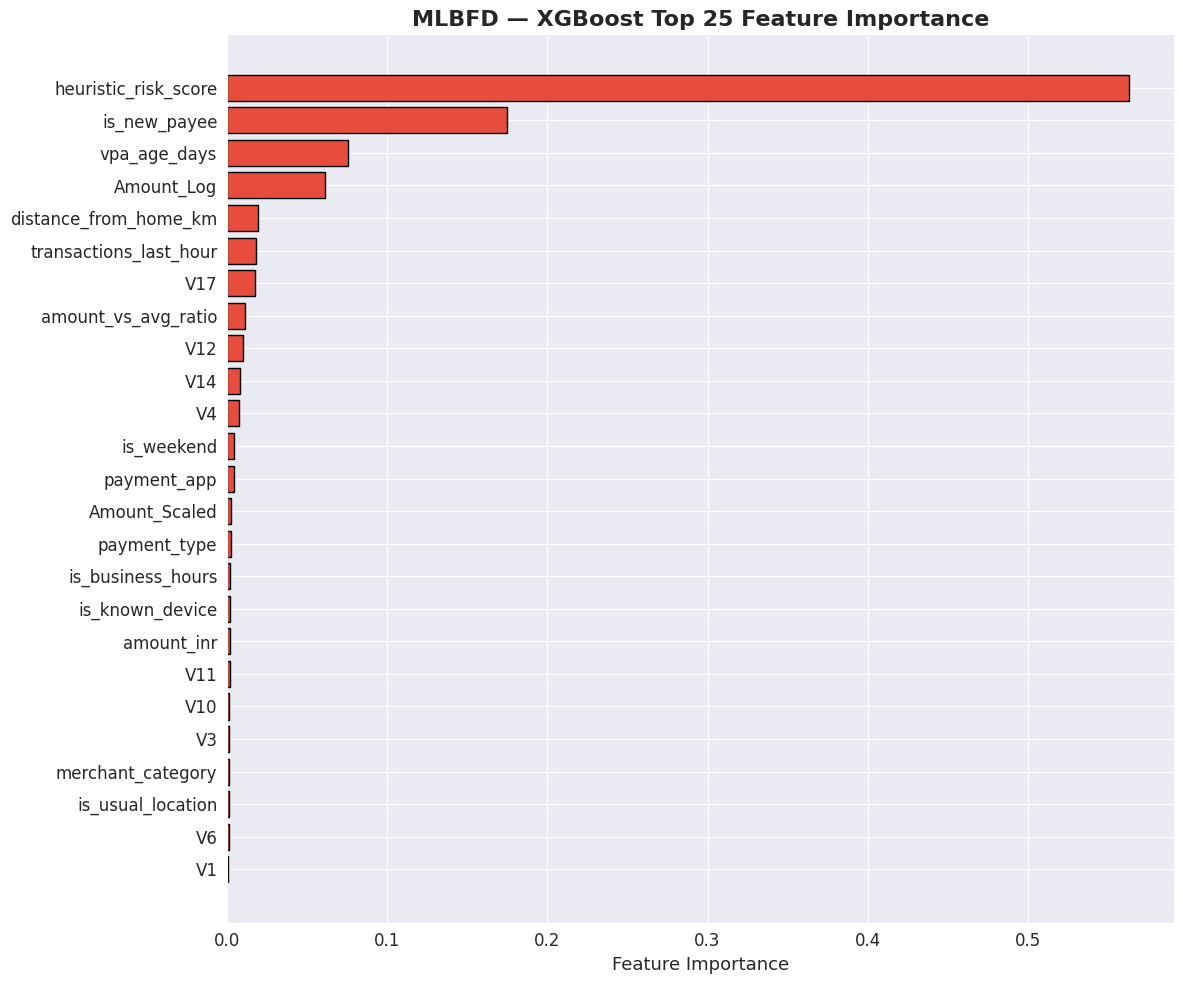

✅ Saved: mlbfd_xgb_feature_importance.png


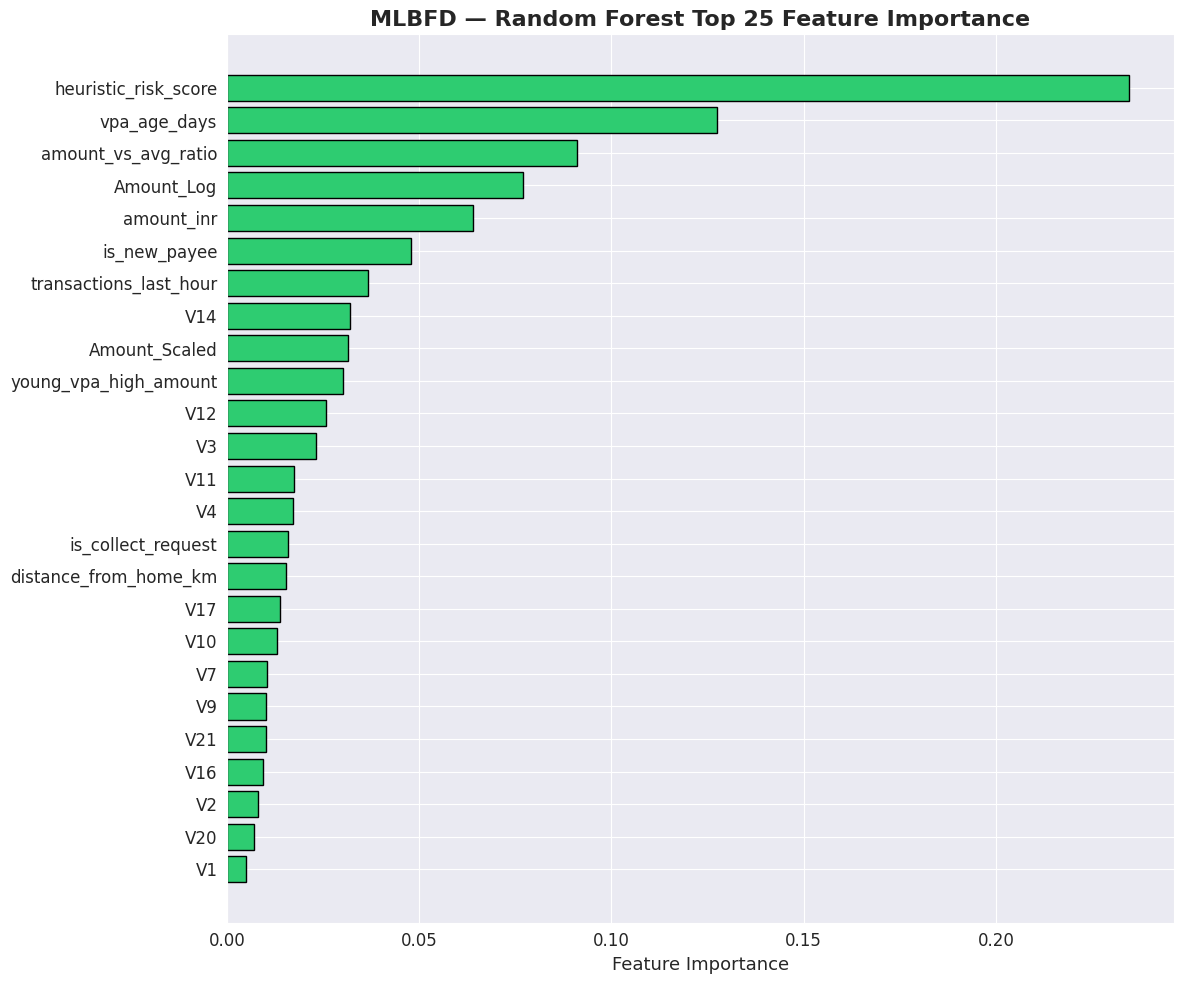

✅ Saved: mlbfd_rf_feature_importance.png

SHAP — SHapley Additive exPlanations
⏳ Computing SHAP values (this may take 2-5 minutes)...

📊 Generating SHAP Summary Plot...


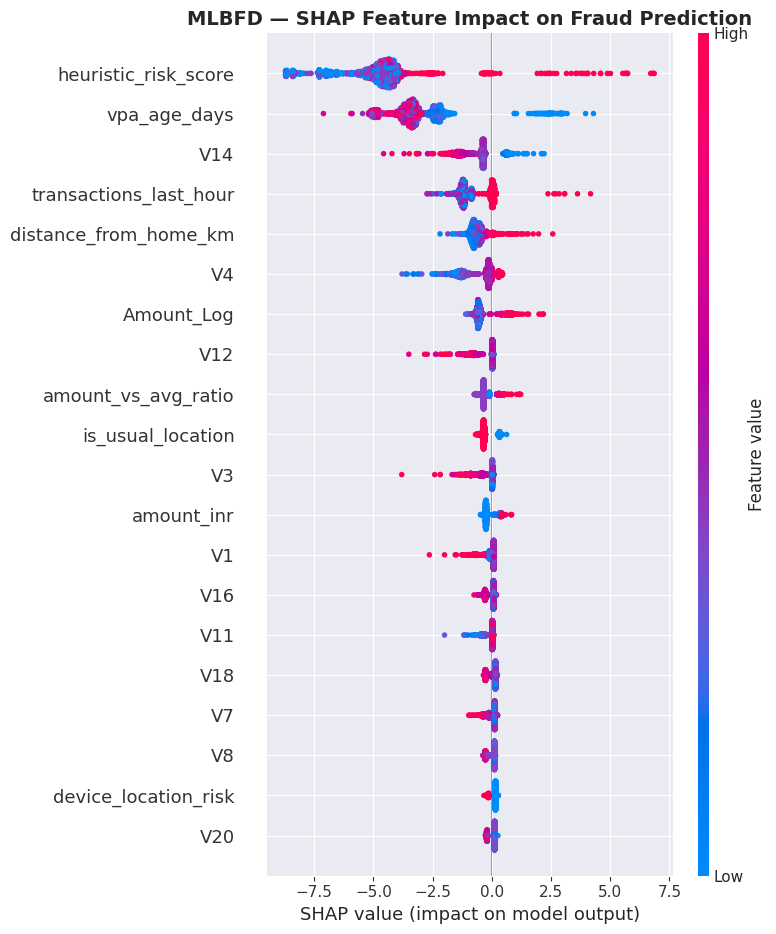

✅ Saved: mlbfd_shap_summary.png
📊 Generating SHAP Bar Plot...


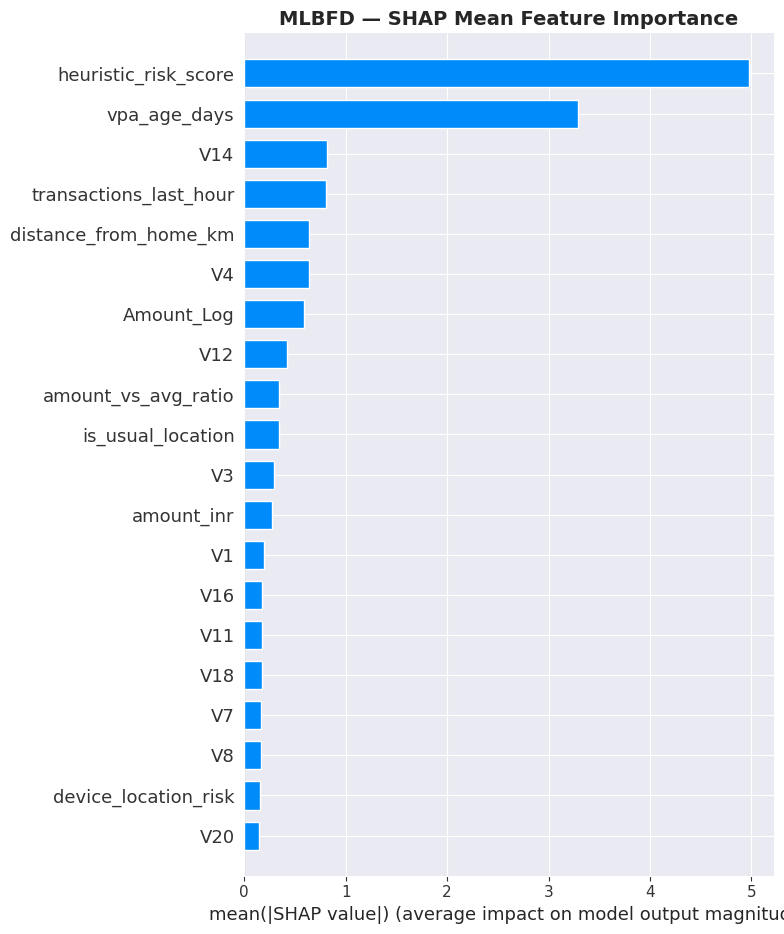

✅ Saved: mlbfd_shap_bar.png

SHAP — INDIVIDUAL FRAUD PREDICTION EXPLANATION

🔍 Explaining fraud transaction at index 22:
   Predicted probability: 100.0%

   Top reasons for flagging:
   • heuristic_risk_score           → SHAP: +4.0290 (↑ INCREASES fraud risk)
   • transactions_last_hour         → SHAP: +3.0807 (↑ INCREASES fraud risk)
   • vpa_age_days                   → SHAP: +2.9156 (↑ INCREASES fraud risk)
   • V14                            → SHAP: +1.0896 (↑ INCREASES fraud risk)
   • V17                            → SHAP: +1.0421 (↑ INCREASES fraud risk)
   • distance_from_home_km          → SHAP: -0.7397 (↓ DECREASES fraud risk)
   • Amount_Log                     → SHAP: -0.4154 (↓ DECREASES fraud risk)
   • V4                             → SHAP: +0.3934 (↑ INCREASES fraud risk)
   • is_usual_location              → SHAP: +0.3220 (↑ INCREASES fraud risk)
   • amount_vs_avg_ratio            → SHAP: -0.2989 (↓ DECREASES fraud risk)

📊 Generating SHAP Force Plot for this fraud c

<Figure size 2000x300 with 0 Axes>

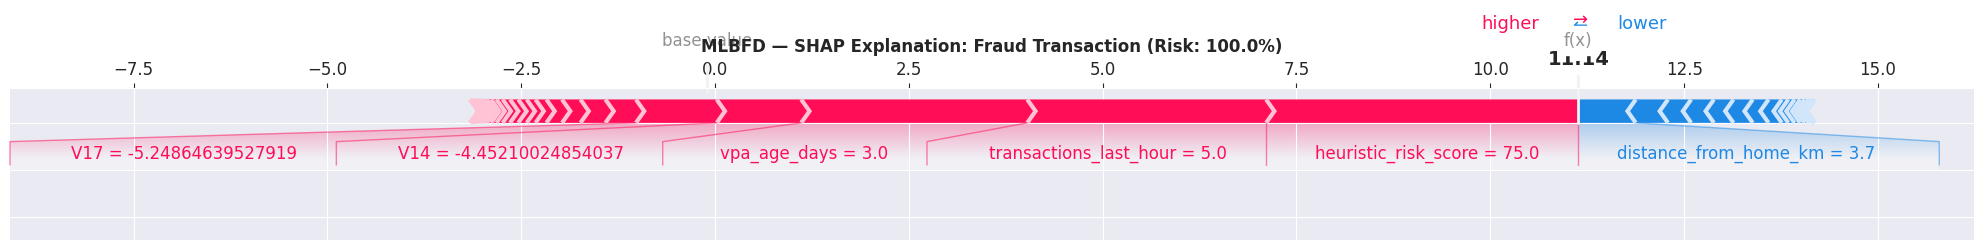

✅ Saved: mlbfd_shap_force_plot.png

✅ Cell 4 Complete — SHAP explainability done!
→ Run Cell 5: UBTS + LSTM (Unique Contributions)


In [4]:
# ============================================================
# MLBFD — PHASE 2, CELL 4
# SHAP Explainability + Feature Importance
# ============================================================

import shap

print(f"{'='*60}")
print("SHAP EXPLAINABILITY — XGBoost Model")
print(f"{'='*60}")

# --- XGBoost Feature Importance (Built-in) ---
fig, ax = plt.subplots(figsize=(12, 10))

feature_names = X.columns.tolist()
importance = trained_models['XGBoost'].feature_importances_

# Sort by importance
sorted_idx = np.argsort(importance)[-25:]  # Top 25
ax.barh(range(len(sorted_idx)), importance[sorted_idx], color='#e74c3c', edgecolor='black')
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx])
ax.set_xlabel('Feature Importance', fontsize=13)
ax.set_title('MLBFD — XGBoost Top 25 Feature Importance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('mlbfd_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: mlbfd_xgb_feature_importance.png")

# --- Random Forest Feature Importance ---
fig, ax = plt.subplots(figsize=(12, 10))

rf_importance = trained_models['Random Forest'].feature_importances_
sorted_idx_rf = np.argsort(rf_importance)[-25:]
ax.barh(range(len(sorted_idx_rf)), rf_importance[sorted_idx_rf], color='#2ecc71', edgecolor='black')
ax.set_yticks(range(len(sorted_idx_rf)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx_rf])
ax.set_xlabel('Feature Importance', fontsize=13)
ax.set_title('MLBFD — Random Forest Top 25 Feature Importance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('mlbfd_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: mlbfd_rf_feature_importance.png")

# --- SHAP Analysis ---
print(f"\n{'='*60}")
print("SHAP — SHapley Additive exPlanations")
print(f"{'='*60}")
print("⏳ Computing SHAP values (this may take 2-5 minutes)...\n")

# Use a sample for SHAP (full dataset is too large)
shap_sample_size = 2000
X_shap = pd.DataFrame(X_test_tree[:shap_sample_size], columns=feature_names)

explainer = shap.TreeExplainer(trained_models['XGBoost'])
shap_values = explainer.shap_values(X_shap)

# SHAP Summary Plot (Beeswarm)
print("📊 Generating SHAP Summary Plot...")
fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.title('MLBFD — SHAP Feature Impact on Fraud Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mlbfd_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: mlbfd_shap_summary.png")

# SHAP Bar Plot
print("📊 Generating SHAP Bar Plot...")
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=20, show=False)
plt.title('MLBFD — SHAP Mean Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mlbfd_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: mlbfd_shap_bar.png")

# --- SHAP for Individual Fraud Prediction (Demo-ready) ---
print(f"\n{'='*60}")
print("SHAP — INDIVIDUAL FRAUD PREDICTION EXPLANATION")
print(f"{'='*60}")

# Find a fraud case in test set
fraud_indices = np.where(y_test.values[:shap_sample_size] == 1)[0]
if len(fraud_indices) > 0:
    fraud_idx = fraud_indices[0]
    print(f"\n🔍 Explaining fraud transaction at index {fraud_idx}:")
    print(f"   Predicted probability: {xgb_prob[fraud_idx]*100:.1f}%")
    print(f"\n   Top reasons for flagging:")

    feature_shap = list(zip(feature_names, shap_values[fraud_idx]))
    feature_shap.sort(key=lambda x: abs(x[1]), reverse=True)

    for feat, val in feature_shap[:10]:
        direction = "↑ INCREASES" if val > 0 else "↓ DECREASES"
        risk = "fraud risk" if val > 0 else "fraud risk"
        print(f"   • {feat:30s} → SHAP: {val:+.4f} ({direction} {risk})")

    # SHAP Force Plot for this prediction
    print("\n📊 Generating SHAP Force Plot for this fraud case...")
    shap.initjs()
    fig = plt.figure(figsize=(20, 3))
    shap.force_plot(
        explainer.expected_value, shap_values[fraud_idx],
        X_shap.iloc[fraud_idx], matplotlib=True, show=False
    )
    plt.title(f'MLBFD — SHAP Explanation: Fraud Transaction (Risk: {xgb_prob[fraud_idx]*100:.1f}%)',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('mlbfd_shap_force_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: mlbfd_shap_force_plot.png")

print(f"\n✅ Cell 4 Complete — SHAP explainability done!")
print(f"→ Run Cell 5: UBTS + LSTM (Unique Contributions)")

UNIQUE CONTRIBUTION 1: USER BEHAVIORAL TRUST SCORE (UBTS)
✅ UBTS initialized with 1000 user profiles

──────────────────────────────────────────────────
UBTS DEMO — Sample Transaction Scoring
──────────────────────────────────────────────────

✅ NORMAL Transaction:
   User: USR_0001 | Amount: ₹500 | Time: 2:00 PM
   UBTS Score: 100/100 (🟢 TRUSTED)
   • All parameters match user's baseline behavior

🔴 SUSPICIOUS Transaction:
   User: USR_0001 | Amount: ₹45,000 | Time: 3:00 AM
   UBTS Score: 0/100 (🔴 SUSPICIOUS)
   • Amount 34.9x higher than usual (-30)
   • Transaction at 3:00 IST — outside usual hours (-15)
   • Location 1200km from home — interstate (-20)
   • Unknown/new device detected (-15)
   • Sending to unknown/new payee (-10)
   • Using BHIM instead of usual GPay (-5)
   • Payee VPA only 3 days old (-10)

──────────────────────────────────────────────────
Generating UBTS test data from ML-ready dataset...
──────────────────────────────────────────────────


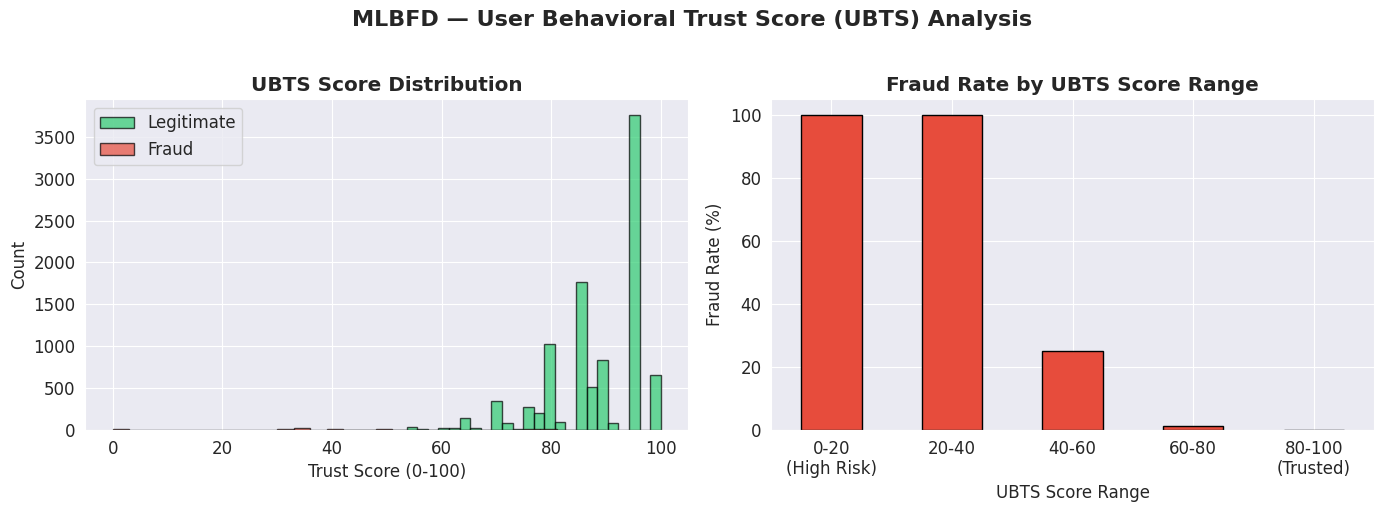

✅ Saved: mlbfd_ubts_analysis.png

📊 UBTS Results:
   Avg Trust Score (Legitimate): 88.2/100
   Avg Trust Score (Fraud):      41.9/100
   Score Gap:                     46.3 points

UNIQUE CONTRIBUTION 2: LSTM TEMPORAL SEQUENCE ANALYSIS

📊 Preparing transaction sequences (last 10 per user)...
  Using 11 features for LSTM sequences
✅ Sequences created: 100,116
   Shape: (100116, 10, 11) (samples, timesteps=10, features=11)
   Fraud sequences: 835 (0.83%)

   After SMOTE: 158,848 sequences (balanced)

──────────────────────────────────────────────────
TRAINING LSTM MODEL
──────────────────────────────────────────────────


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,417 (126.63 KB)

 Trainable params: 32,417 (126.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - accuracy: 0.6071 - loss: 0.6515 - val_accuracy: 0.6318 - val_loss: 0.6439
Epoch 2/30
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.8343 - loss: 0.3789 - val_accuracy: 0.9050 - val_loss: 0.1968
Epoch 3/30
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.8864 - loss: 0.2779 - val_accuracy: 0.7249 - val_loss: 0.5140
Epoch 4/30
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.9020 - loss: 0.2452 - val_accuracy: 0.7401 - val_loss: 0.5153
Epoch 5/30
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.9097 - loss: 0.2277 - val_accuracy: 0.8283 - val_loss: 0.3300
Epoch 6/30
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - accuracy: 0.9147 - loss: 0.2181 - val_accuracy: 0.8209 - val_loss: 0.3524
Epoch 7/30
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.9182 - loss: 0.2077 - val_accuracy: 0.8932 - val_loss: 0.2121
Epoch 7: early stopping
Restoring model weights from the end of the best epo

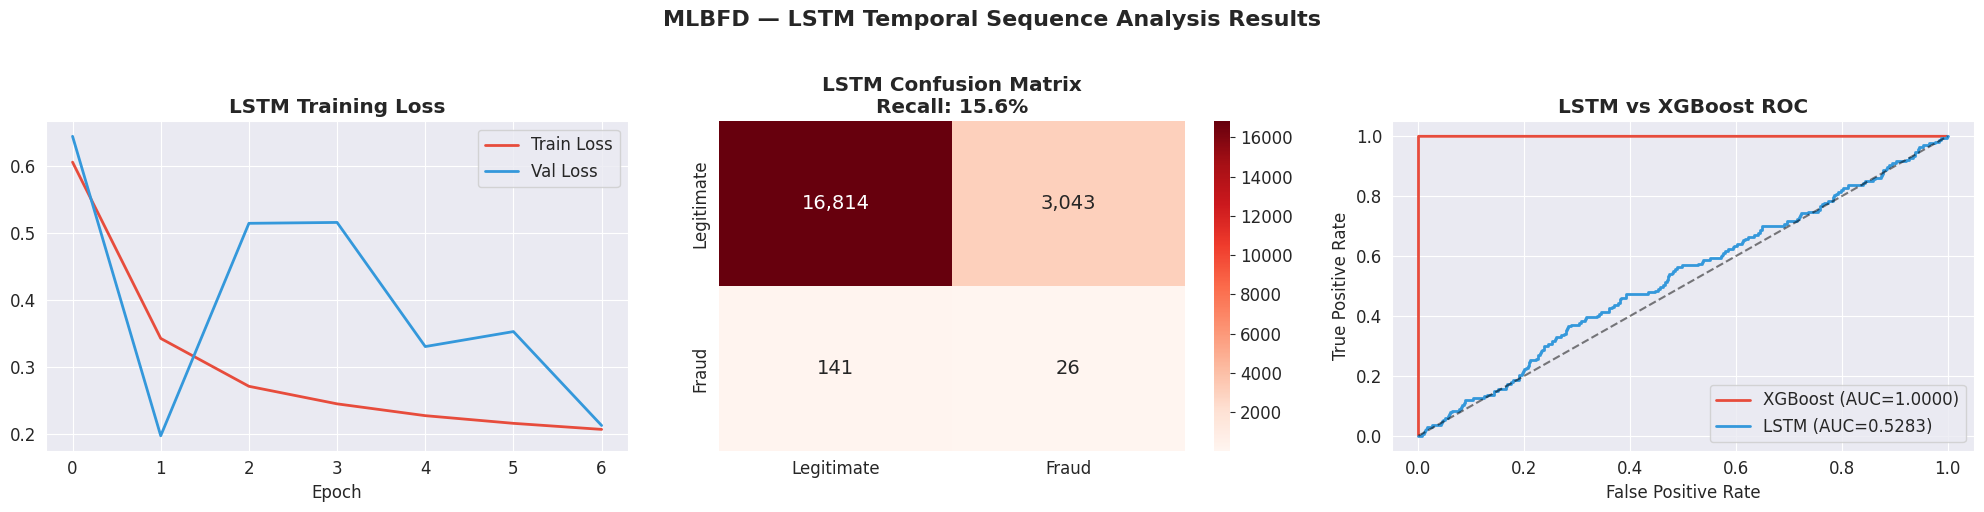

✅ Saved: mlbfd_lstm_results.png

──────────────────────────────────────────────────
LSTM DEMO — Detecting Gradual Escalation
──────────────────────────────────────────────────

How LSTM catches fraud that XGBoost misses:

T-10: ₹500  (GPay, food, Mumbai)     → NORMAL
T-9:  ₹200  (Paytm, transport)       → NORMAL
T-8:  ₹1000 (PhonePe, shopping)      → NORMAL
T-7:  ₹300  (GPay, food)             → NORMAL
T-6:  ₹800  (known merchant)         → NORMAL
T-5:  ₹2000 (new merchant)           → SLIGHT ANOMALY
T-4:  ₹5000 (unknown VPA)            → ANOMALY
T-3:  ₹8000 (different city)         → HIGH ANOMALY
T-2:  ₹15000 (new device)            → CRITICAL
T-1:  ₹45000 (Unknown VPA, 3AM)      ← FRAUD IN SEQUENCE

XGBoost: Analyzes T-1 ALONE → might miss context
LSTM:    Sees the ESCALATION PATTERN → catches it!


✅ Cell 5 Complete — Both unique contributions implemented!
→ Run Cell 6: Save all models & final summary


In [6]:
# ============================================================
# MLBFD — PHASE 2, CELL 5 (FIXED)
# UNIQUE CONTRIBUTION 1: User Behavioral Trust Score (UBTS)
# UNIQUE CONTRIBUTION 2: LSTM Temporal Sequence Analysis
# ============================================================

print(f"{'='*60}")
print("UNIQUE CONTRIBUTION 1: USER BEHAVIORAL TRUST SCORE (UBTS)")
print(f"{'='*60}")

# ============================================================
# UBTS — User Behavioral Trust Score
# ============================================================

class UserBehavioralTrustScore:
    """
    UBTS: Builds personalized spending baseline per user
    and scores current transactions against their history.

    Unique Contribution: No existing paper builds per-user
    Indian UPI behavioral profiles for fraud detection.
    """

    def __init__(self, user_profiles_df):
        self.profiles = {}
        self._build_profiles(user_profiles_df)

    def _build_profiles(self, df):
        """Build baseline profiles from user data"""
        for _, row in df.iterrows():
            self.profiles[row['user_id']] = {
                'avg_amount': row['avg_amount'],
                'max_usual_amount': row['max_usual_amount'],
                'usual_hour_start': row['usual_hour_start'],
                'usual_hour_end': row['usual_hour_end'],
                'preferred_app': row['preferred_app'],
                'home_state': row['home_state'],
                'home_city': row['home_city'],
                'avg_daily_txn': row['avg_daily_transactions'],
                'account_age': row['account_age_days'],
                'device_id': row['device_id']
            }

    def calculate_trust_score(self, transaction):
        """
        Calculate UBTS for a single transaction.
        Returns score 0-100 (higher = more trustworthy)
        """
        user_id = transaction.get('user_id', '')
        profile = self.profiles.get(user_id, None)

        if profile is None:
            return 20, ["Unknown user — low trust by default"]

        score = 100
        reasons = []

        # 1. Amount deviation (max -30 points)
        amount = transaction.get('amount_inr', 0)
        amount_ratio = amount / max(profile['avg_amount'], 1)
        if amount_ratio > 10:
            penalty = min(30, int(amount_ratio * 2))
            score -= penalty
            reasons.append(f"Amount {amount_ratio:.1f}x higher than usual (-{penalty})")
        elif amount_ratio > 5:
            penalty = min(20, int(amount_ratio))
            score -= penalty
            reasons.append(f"Amount {amount_ratio:.1f}x higher than usual (-{penalty})")
        elif amount_ratio > 3:
            score -= 10
            reasons.append(f"Amount {amount_ratio:.1f}x higher than usual (-10)")

        # 2. Time deviation (max -15 points)
        hour = transaction.get('hour_ist', 12)
        if hour < profile['usual_hour_start'] or hour > profile['usual_hour_end']:
            if hour >= 23 or hour <= 5:
                score -= 15
                reasons.append(f"Transaction at {hour}:00 IST — outside usual hours (-15)")
            else:
                score -= 8
                reasons.append(f"Transaction at {hour}:00 IST — slightly unusual (-8)")

        # 3. Location deviation (max -20 points)
        if transaction.get('is_usual_location', 1) == 0:
            distance = transaction.get('distance_from_home_km', 0)
            if distance > 500:
                score -= 20
                reasons.append(f"Location {distance:.0f}km from home — interstate (-20)")
            elif distance > 100:
                score -= 12
                reasons.append(f"Location {distance:.0f}km from home — different city (-12)")
            else:
                score -= 5
                reasons.append(f"Slightly unusual location (-5)")

        # 4. Device check (max -15 points)
        if transaction.get('is_known_device', 1) == 0:
            score -= 15
            reasons.append("Unknown/new device detected (-15)")

        # 5. New payee check (max -10 points)
        if transaction.get('is_new_payee', 0) == 1:
            score -= 10
            reasons.append("Sending to unknown/new payee (-10)")

        # 6. Payment app deviation (max -5 points)
        app = transaction.get('payment_app', '')
        if app and app != profile['preferred_app']:
            score -= 5
            reasons.append(f"Using {app} instead of usual {profile['preferred_app']} (-5)")

        # 7. Velocity check (max -10 points)
        txn_last_hour = transaction.get('transactions_last_hour', 0)
        if txn_last_hour > profile['avg_daily_txn']:
            score -= 10
            reasons.append(f"High velocity: {txn_last_hour} txns in last hour (-10)")

        # 8. VPA age check (max -10 points)
        vpa_age = transaction.get('vpa_age_days', 365)
        if vpa_age < 7:
            score -= 10
            reasons.append(f"Payee VPA only {vpa_age} days old (-10)")
        elif vpa_age < 30:
            score -= 5
            reasons.append(f"Payee VPA only {vpa_age} days old (-5)")

        score = max(0, min(100, score))
        return score, reasons


# Initialize UBTS
ubts = UserBehavioralTrustScore(df_users)
print(f"✅ UBTS initialized with {len(ubts.profiles)} user profiles\n")

# --- Test UBTS with sample transactions ---
print(f"{'─'*50}")
print("UBTS DEMO — Sample Transaction Scoring")
print(f"{'─'*50}")

# Normal transaction
normal_txn = {
    'user_id': 'USR_0001',
    'amount_inr': 500,
    'hour_ist': 14,
    'is_usual_location': 1,
    'distance_from_home_km': 5,
    'is_known_device': 1,
    'is_new_payee': 0,
    'payment_app': df_users.iloc[0]['preferred_app'],
    'transactions_last_hour': 1,
    'vpa_age_days': 200
}
score, reasons = ubts.calculate_trust_score(normal_txn)
print(f"\n✅ NORMAL Transaction:")
print(f"   User: USR_0001 | Amount: ₹500 | Time: 2:00 PM")
print(f"   UBTS Score: {score}/100 ({'🟢 TRUSTED' if score >= 70 else '🟡 CAUTION' if score >= 40 else '🔴 SUSPICIOUS'})")
if reasons:
    for r in reasons:
        print(f"   • {r}")
else:
    print(f"   • All parameters match user's baseline behavior")

# Suspicious transaction
fraud_txn = {
    'user_id': 'USR_0001',
    'amount_inr': 45000,
    'hour_ist': 3,
    'is_usual_location': 0,
    'distance_from_home_km': 1200,
    'is_known_device': 0,
    'is_new_payee': 1,
    'payment_app': 'BHIM',
    'transactions_last_hour': 6,
    'vpa_age_days': 3
}
score2, reasons2 = ubts.calculate_trust_score(fraud_txn)
print(f"\n🔴 SUSPICIOUS Transaction:")
print(f"   User: USR_0001 | Amount: ₹45,000 | Time: 3:00 AM")
print(f"   UBTS Score: {score2}/100 ({'🟢 TRUSTED' if score2 >= 70 else '🟡 CAUTION' if score2 >= 40 else '🔴 SUSPICIOUS'})")
for r in reasons2:
    print(f"   • {r}")

# --- 🔧 FIX: Generate Indian data directly instead of loading file ---
print(f"\n{'─'*50}")
print("Generating UBTS test data from ML-ready dataset...")
print(f"{'─'*50}")

# Create a subset with user IDs that match our profiles (USR_ prefix)
# We'll use the ml_ready data and reconstruct what we need
df_ml_copy = df_ml.copy()

# Assign user IDs from our profiles for UBTS scoring
num_rows = len(df_ml_copy)
user_ids = [f'USR_{(i % 1000) + 1:04d}' for i in range(num_rows)]
df_ml_copy['user_id'] = user_ids

# Map encoded columns back for UBTS (approximate)
payment_apps_list = ['GPay', 'PhonePe', 'Paytm', 'BHIM', 'AmazonPay', 'WhatsAppPay', 'Bank']

# Calculate UBTS scores on a sample (full dataset would take too long)
sample_size = 10000
df_ubts_sample = df_ml_copy.sample(n=min(sample_size, len(df_ml_copy)), random_state=42)

ubts_scores = []
for _, row in df_ubts_sample.iterrows():
    txn = {
        'user_id': row['user_id'],
        'amount_inr': row.get('amount_inr', 0),
        'hour_ist': row.get('hour_ist', 12),
        'is_usual_location': row.get('is_usual_location', 1),
        'distance_from_home_km': row.get('distance_from_home_km', 0),
        'is_known_device': row.get('is_known_device', 1),
        'is_new_payee': row.get('is_new_payee', 0),
        'payment_app': payment_apps_list[int(row.get('payment_app', 0)) % len(payment_apps_list)],
        'transactions_last_hour': row.get('transactions_last_hour', 0),
        'vpa_age_days': row.get('vpa_age_days', 365)
    }
    score_val, _ = ubts.calculate_trust_score(txn)
    ubts_scores.append(score_val)

df_ubts_sample['ubts_score'] = ubts_scores

# UBTS Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_ubts_sample[df_ubts_sample['is_fraud']==0]['ubts_score'],
             bins=30, color='#2ecc71', alpha=0.7, label='Legitimate', edgecolor='black')
axes[0].hist(df_ubts_sample[df_ubts_sample['is_fraud']==1]['ubts_score'],
             bins=30, color='#e74c3c', alpha=0.7, label='Fraud', edgecolor='black')
axes[0].set_title('UBTS Score Distribution', fontweight='bold')
axes[0].set_xlabel('Trust Score (0-100)')
axes[0].set_ylabel('Count')
axes[0].legend()

# UBTS as fraud predictor
ubts_bins = pd.cut(df_ubts_sample['ubts_score'], bins=[0, 20, 40, 60, 80, 100], include_lowest=True)
ubts_fraud_rate = df_ubts_sample.groupby(ubts_bins, observed=True)['is_fraud'].mean() * 100
ubts_fraud_rate.plot(kind='bar', ax=axes[1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Fraud Rate by UBTS Score Range', fontweight='bold')
axes[1].set_xlabel('UBTS Score Range')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xticklabels(['0-20\n(High Risk)', '20-40', '40-60', '60-80', '80-100\n(Trusted)'],
                         rotation=0)

plt.suptitle('MLBFD — User Behavioral Trust Score (UBTS) Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mlbfd_ubts_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: mlbfd_ubts_analysis.png")

avg_legit = df_ubts_sample[df_ubts_sample['is_fraud']==0]['ubts_score'].mean()
avg_fraud = df_ubts_sample[df_ubts_sample['is_fraud']==1]['ubts_score'].mean()
print(f"\n📊 UBTS Results:")
print(f"   Avg Trust Score (Legitimate): {avg_legit:.1f}/100")
print(f"   Avg Trust Score (Fraud):      {avg_fraud:.1f}/100")
print(f"   Score Gap:                     {avg_legit - avg_fraud:.1f} points")

# ============================================================
# UNIQUE CONTRIBUTION 2: LSTM TEMPORAL SEQUENCE ANALYSIS
# ============================================================
print(f"\n{'='*60}")
print("UNIQUE CONTRIBUTION 2: LSTM TEMPORAL SEQUENCE ANALYSIS")
print(f"{'='*60}")

from tensorflow.keras.models import Sequential as SeqModel
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping as ES
from sklearn.preprocessing import MinMaxScaler

# --- Prepare Sequence Data ---
print("\n📊 Preparing transaction sequences (last 10 per user)...")

SEQUENCE_LENGTH = 10

# 🔧 FIX: Use ml_ready data with assigned user_ids
lstm_features = ['amount_inr', 'hour_ist', 'is_new_payee', 'is_known_device',
                 'is_usual_location', 'distance_from_home_km', 'vpa_age_days',
                 'transactions_last_hour', 'amount_vs_avg_ratio', 'is_vpn',
                 'is_collect_request']

# Check which features exist in our data
available_lstm_features = [f for f in lstm_features if f in df_ml_copy.columns]
missing_features = [f for f in lstm_features if f not in df_ml_copy.columns]

if missing_features:
    print(f"  ⚠️ Missing features (will use zeros): {missing_features}")
    for mf in missing_features:
        df_ml_copy[mf] = 0

print(f"  Using {len(lstm_features)} features for LSTM sequences")

# Sort by user (simulate temporal ordering)
df_seq = df_ml_copy.copy()
df_seq = df_seq.sort_values('user_id').reset_index(drop=True)

# Add a synthetic timestamp for ordering within each user
df_seq['seq_order'] = df_seq.groupby('user_id').cumcount()
df_seq = df_seq.sort_values(['user_id', 'seq_order']).reset_index(drop=True)

# Scale features for LSTM
lstm_scaler = MinMaxScaler()
df_seq[lstm_features] = lstm_scaler.fit_transform(df_seq[lstm_features].fillna(0))

# Build sequences
sequences = []
labels = []

user_groups = df_seq.groupby('user_id')
for user_id, group in user_groups:
    if len(group) < SEQUENCE_LENGTH + 1:
        continue

    feature_data = group[lstm_features].values
    fraud_labels = group['is_fraud'].values

    for i in range(SEQUENCE_LENGTH, len(group)):
        seq = feature_data[i-SEQUENCE_LENGTH:i]
        label = fraud_labels[i]
        sequences.append(seq)
        labels.append(label)

    # Limit sequences per user to avoid memory issues
    if len(sequences) > 100000:
        break

X_lstm = np.array(sequences)
y_lstm = np.array(labels)

print(f"✅ Sequences created: {len(X_lstm):,}")
print(f"   Shape: {X_lstm.shape} (samples, timesteps={SEQUENCE_LENGTH}, features={len(lstm_features)})")
print(f"   Fraud sequences: {y_lstm.sum():,} ({y_lstm.mean()*100:.2f}%)")

# --- Train/Test Split for LSTM ---
X_lstm_train, X_lstm_test, y_lstm_train, y_lstm_test = train_test_split(
    X_lstm, y_lstm, test_size=0.2, random_state=42, stratify=y_lstm
)

# SMOTE on flattened sequences
X_lstm_train_flat = X_lstm_train.reshape(X_lstm_train.shape[0], -1)
smote_lstm = SMOTE(random_state=42)
X_lstm_train_smote, y_lstm_train_smote = smote_lstm.fit_resample(X_lstm_train_flat, y_lstm_train)
X_lstm_train_smote = X_lstm_train_smote.reshape(-1, SEQUENCE_LENGTH, len(lstm_features))

print(f"\n   After SMOTE: {len(X_lstm_train_smote):,} sequences (balanced)")

# --- Build LSTM Model ---
print(f"\n{'─'*50}")
print("TRAINING LSTM MODEL")
print(f"{'─'*50}")

lstm_model = SeqModel([
    LSTM(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, len(lstm_features))),
    Dropout(0.3),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

early_stop_lstm = ES(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

start = time.time()
lstm_history = lstm_model.fit(
    X_lstm_train_smote, y_lstm_train_smote,
    epochs=30,
    batch_size=128,
    validation_split=0.15,
    callbacks=[early_stop_lstm],
    verbose=1
)
lstm_time = time.time() - start

# --- Evaluate LSTM ---
lstm_prob = lstm_model.predict(X_lstm_test, verbose=0).flatten()
lstm_pred = (lstm_prob >= 0.5).astype(int)

lstm_accuracy = accuracy_score(y_lstm_test, lstm_pred)
lstm_recall = recall_score(y_lstm_test, lstm_pred)
lstm_precision = precision_score(y_lstm_test, lstm_pred)
lstm_f1 = f1_score(y_lstm_test, lstm_pred)
lstm_auc = roc_auc_score(y_lstm_test, lstm_prob)

print(f"\n{'='*60}")
print("LSTM TEMPORAL SEQUENCE ANALYSIS — RESULTS")
print(f"{'='*60}")
print(f"  Accuracy  : {lstm_accuracy*100:.2f}%")
print(f"  Precision : {lstm_precision*100:.2f}%")
print(f"  Recall    : {lstm_recall*100:.2f}%")
print(f"  F1 Score  : {lstm_f1*100:.2f}%")
print(f"  AUC       : {lstm_auc:.4f}")
print(f"  Train Time: {lstm_time:.2f}s")

# --- LSTM Visualizations ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Training history
axes[0].plot(lstm_history.history['loss'], label='Train Loss', color='#e74c3c', linewidth=2)
axes[0].plot(lstm_history.history['val_loss'], label='Val Loss', color='#3498db', linewidth=2)
axes[0].set_title('LSTM Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Confusion matrix
cm_lstm = confusion_matrix(y_lstm_test, lstm_pred)
sns.heatmap(cm_lstm, annot=True, fmt=',', cmap='Reds', ax=axes[1],
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'],
            annot_kws={'size': 14})
axes[1].set_title(f'LSTM Confusion Matrix\nRecall: {lstm_recall*100:.1f}%', fontweight='bold')

# ROC Curve comparison with XGBoost
fpr_lstm, tpr_lstm, _ = roc_curve(y_lstm_test, lstm_prob)
fpr_xgb_main, tpr_xgb_main, _ = roc_curve(y_test, xgb_prob)

axes[2].plot(fpr_xgb_main, tpr_xgb_main, color='#e74c3c', linewidth=2,
             label=f'XGBoost (AUC={results["XGBoost"]["auc"]:.4f})')
axes[2].plot(fpr_lstm, tpr_lstm, color='#3498db', linewidth=2,
             label=f'LSTM (AUC={lstm_auc:.4f})')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[2].set_title('LSTM vs XGBoost ROC', fontweight='bold')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()

plt.suptitle('MLBFD — LSTM Temporal Sequence Analysis Results',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mlbfd_lstm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: mlbfd_lstm_results.png")

# --- LSTM Sequence Anomaly Demo ---
print(f"\n{'─'*50}")
print("LSTM DEMO — Detecting Gradual Escalation")
print(f"{'─'*50}")
print("""
How LSTM catches fraud that XGBoost misses:

T-10: ₹500  (GPay, food, Mumbai)     → NORMAL
T-9:  ₹200  (Paytm, transport)       → NORMAL
T-8:  ₹1000 (PhonePe, shopping)      → NORMAL
T-7:  ₹300  (GPay, food)             → NORMAL
T-6:  ₹800  (known merchant)         → NORMAL
T-5:  ₹2000 (new merchant)           → SLIGHT ANOMALY
T-4:  ₹5000 (unknown VPA)            → ANOMALY
T-3:  ₹8000 (different city)         → HIGH ANOMALY
T-2:  ₹15000 (new device)            → CRITICAL
T-1:  ₹45000 (Unknown VPA, 3AM)      ← FRAUD IN SEQUENCE

XGBoost: Analyzes T-1 ALONE → might miss context
LSTM:    Sees the ESCALATION PATTERN → catches it!
""")

print(f"\n✅ Cell 5 Complete — Both unique contributions implemented!")
print(f"→ Run Cell 6: Save all models & final summary")

In [8]:
# ============================================================
# MLBFD — PHASE 2, CELL 6 (FIXED)
# Save All Models & Final Phase 2 Summary
# ============================================================

import pickle
import os

print(f"{'='*60}")
print("SAVING ALL TRAINED MODELS")
print(f"{'='*60}")

# --- Save XGBoost (Primary Model) ---
with open('mlbfd_xgboost_model.pkl', 'wb') as f:
    pickle.dump(trained_models['XGBoost'], f)
print(f"✅ Saved: mlbfd_xgboost_model.pkl")

# --- Save Random Forest ---
with open('mlbfd_random_forest_model.pkl', 'wb') as f:
    pickle.dump(trained_models['Random Forest'], f)
print(f"✅ Saved: mlbfd_random_forest_model.pkl")

# --- Save Logistic Regression ---
with open('mlbfd_logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(trained_models['Logistic Regression'], f)
print(f"✅ Saved: mlbfd_logistic_regression_model.pkl")

# --- Save Isolation Forest ---
with open('mlbfd_isolation_forest_model.pkl', 'wb') as f:
    pickle.dump(trained_models['Isolation Forest'], f)
print(f"✅ Saved: mlbfd_isolation_forest_model.pkl")

# --- Save Neural Network ---
trained_models['Neural Network'].save('mlbfd_neural_network_model.keras')
print(f"✅ Saved: mlbfd_neural_network_model.keras")

# --- Save LSTM ---
lstm_model.save('mlbfd_lstm_model.keras')
print(f"✅ Saved: mlbfd_lstm_model.keras")

# --- Save Scalers ---
with open('mlbfd_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"✅ Saved: mlbfd_scaler.pkl")

with open('mlbfd_lstm_scaler.pkl', 'wb') as f:
    pickle.dump(lstm_scaler, f)
print(f"✅ Saved: mlbfd_lstm_scaler.pkl")

# --- Save UBTS ---
with open('mlbfd_ubts.pkl', 'wb') as f:
    pickle.dump(ubts, f)
print(f"✅ Saved: mlbfd_ubts.pkl")

# --- Save Feature Names ---
with open('mlbfd_feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)
print(f"✅ Saved: mlbfd_feature_names.pkl")

# --- Save Results Dictionary ---
results_save = {}
for name, metrics in results.items():
    results_save[name] = {
        'accuracy': metrics['accuracy'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1'],
        'auc': metrics['auc'],
        'train_time': metrics['train_time']
    }

# Add LSTM results
results_save['LSTM'] = {
    'accuracy': lstm_accuracy,
    'precision': lstm_precision,
    'recall': lstm_recall,
    'f1': lstm_f1,
    'auc': lstm_auc,
    'train_time': lstm_time
}

with open('mlbfd_results.pkl', 'wb') as f:
    pickle.dump(results_save, f)
print(f"✅ Saved: mlbfd_results.pkl")

# ============================================================
# DOWNLOAD EVERYTHING AS ZIP
# ============================================================
print(f"\n{'='*60}")
print("📦 CREATING DOWNLOAD PACKAGE")
print(f"{'='*60}")

import zipfile

zip_filename = 'MLBFD_Phase2_Complete.zip'

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for f in os.listdir('/content'):
        if not f.startswith('mlbfd_'):
            continue

        if f.endswith('.pkl') or f.endswith('.keras'):
            zip_path = f'MLBFD_Phase2/Models/{f}'
        elif f.endswith('.png'):
            zip_path = f'MLBFD_Phase2/Visualizations/{f}'
        elif f.endswith('.csv'):
            zip_path = f'MLBFD_Phase2/Data/{f}'
        else:
            zip_path = f'MLBFD_Phase2/{f}'

        zipf.write(f'/content/{f}', zip_path)
        size = os.path.getsize(f'/content/{f}') / (1024*1024)
        print(f"  ✅ {f:45s} ({size:.2f} MB)")

zip_size = os.path.getsize(zip_filename) / (1024*1024)
print(f"\n📦 ZIP ready: {zip_filename} ({zip_size:.2f} MB)")

# ============================================================
# FINAL COMPREHENSIVE SUMMARY
# ============================================================
print(f"\n{'='*60}")
print("MLBFD — PHASE 2 COMPLETE ✅")
print("Multi-Layer Behavioral Fraud Detection System")
print("for Indian Digital Payments Using Machine Learning")
print(f"{'='*60}")

print(f"\n{'─'*77}")
print("📊 ALL MODELS — FINAL COMPARISON TABLE")
print(f"{'─'*77}")
print(f"\n{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10}")
print(f"{'─'*77}")

for name, metrics in results_save.items():
    star = ' ⭐' if name == 'XGBoost' else ''
    print(f"{name:<25} {metrics['accuracy']*100:>9.2f}% {metrics['precision']*100:>9.2f}% "
          f"{metrics['recall']*100:>9.2f}% {metrics['f1']*100:>9.2f}% "
          f"{metrics['auc']:>9.4f}{star}")

print(f"\n{'─'*77}")

# Find best model
best_name = max(results_save, key=lambda x: results_save[x]['auc'])
print(f"\n🏆 Best Model: {best_name} (AUC: {results_save[best_name]['auc']:.4f})")

print(f"\n📁 Files Saved:")
print(f"   Models       : 6 (.pkl + .keras)")
print(f"   Scalers      : 2 (StandardScaler + MinMaxScaler)")
print(f"   UBTS         : 1 (User Behavioral Trust Score)")
print(f"   Visualizations: All charts saved as .png")
print(f"   Results      : mlbfd_results.pkl")

print(f"\n📊 Visualizations Generated:")
viz_list = [
    'mlbfd_roc_curves.png',
    'mlbfd_confusion_matrices.png',
    'mlbfd_model_comparison.png',
    'mlbfd_precision_recall_curves.png',
    'mlbfd_nn_training_history.png',
    'mlbfd_xgb_feature_importance.png',
    'mlbfd_rf_feature_importance.png',
    'mlbfd_shap_summary.png',
    'mlbfd_shap_bar.png',
    'mlbfd_shap_force_plot.png',
    'mlbfd_ubts_analysis.png',
    'mlbfd_lstm_results.png'
]
for i, v in enumerate(viz_list, 1):
    exists = '✅' if os.path.exists(f'/content/{v}') else '❌'
    print(f"   {i:2d}. {exists} {v}")

print(f"\n{'='*60}")
print("→ NEXT STEPS:")
print("  1. Download: MLBFD_Phase2_Complete.zip")
print("  2. Phase 3: Flask Backend API")
print("     Ask: 'Start Phase 3'")
print(f"{'='*60}")

# --- Auto Download ---
print(f"\n⬇️  Downloading ZIP...")
from google.colab import files
files.download(zip_filename)

SAVING ALL TRAINED MODELS
✅ Saved: mlbfd_xgboost_model.pkl
✅ Saved: mlbfd_random_forest_model.pkl
✅ Saved: mlbfd_logistic_regression_model.pkl
✅ Saved: mlbfd_isolation_forest_model.pkl
✅ Saved: mlbfd_neural_network_model.keras
✅ Saved: mlbfd_lstm_model.keras
✅ Saved: mlbfd_scaler.pkl
✅ Saved: mlbfd_lstm_scaler.pkl
✅ Saved: mlbfd_ubts.pkl
✅ Saved: mlbfd_feature_names.pkl
✅ Saved: mlbfd_results.pkl

📦 CREATING DOWNLOAD PACKAGE
  ✅ mlbfd_rf_feature_importance.png               (0.10 MB)
  ✅ mlbfd_roc_curves.png                          (0.12 MB)
  ✅ mlbfd_lstm_results.png                        (0.18 MB)
  ✅ mlbfd_results.pkl                             (0.00 MB)
  ✅ mlbfd_ubts.pkl                                (0.08 MB)
  ✅ mlbfd_nn_training_history.png                 (0.10 MB)
  ✅ mlbfd_shap_bar.png                            (0.09 MB)
  ✅ mlbfd_shap_force_plot.png                     (0.09 MB)
  ✅ mlbfd_precision_recall_curves.png             (0.08 MB)
  ✅ mlbfd_logistic_regression_m

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>